# Загрузка датасета

In [4]:
import os

In [5]:
dataset_root = os.path.join(os.getcwd(), 'raw_datasets')
dataset_dirs = [os.path.join(dataset_root, name) for name in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root,name))]
dataset_path = dataset_dirs[0]
image_paths = [os.path.join(dataset_path, name) for name in os.listdir(dataset_path) if os.path.isfile(os.path.join(dataset_path,name))]

# Манипуляции с изображением

In [6]:
import tifffile
import numpy as np
from utility import show_numpy_stats

In [7]:
tif = tifffile.TiffFile(image_paths[0])
print(f"Всего каналов у изображения: {len(tif.pages)}")

Всего каналов у изображения: 204


In [8]:
rgb_indices = [88,49,18]

In [9]:
spectral_stack = np.stack([page.asarray() for page in tif.pages], axis=2)
rgb_preview = np.stack([spectral_stack[:,:,i] for i in rgb_indices], axis=2)

print(f"Shape всех каналов: {spectral_stack.shape}")
print(f"Shape RGB-превью: {rgb_preview.shape}")

Shape всех каналов: (48, 352, 204)
Shape RGB-превью: (48, 352, 3)


In [10]:
# print(f"Максимальное значение цвета: {spectral_stack.max()}")
# print(f"Минимальное значение цвета: {spectral_stack.min()}")
# print(f"Среднее значение цвета: {round(spectral_stack.mean(), 3)}")
# print(f"Тип данных: {np.dtype(spectral_stack[0,0,0])}")
show_numpy_stats(spectral_stack)

{'count': 3446784,
 'max': 64963.0,
 'min': 0.0,
 'mean': 2695.4494096525923,
 'median': 0.0,
 'std': 10542.734525932901,
 '25%': 0.0,
 '75%': 0.0,
 'dtype': 'uint16'}


# Просмотр изображения

In [11]:
import matplotlib.pyplot as plt

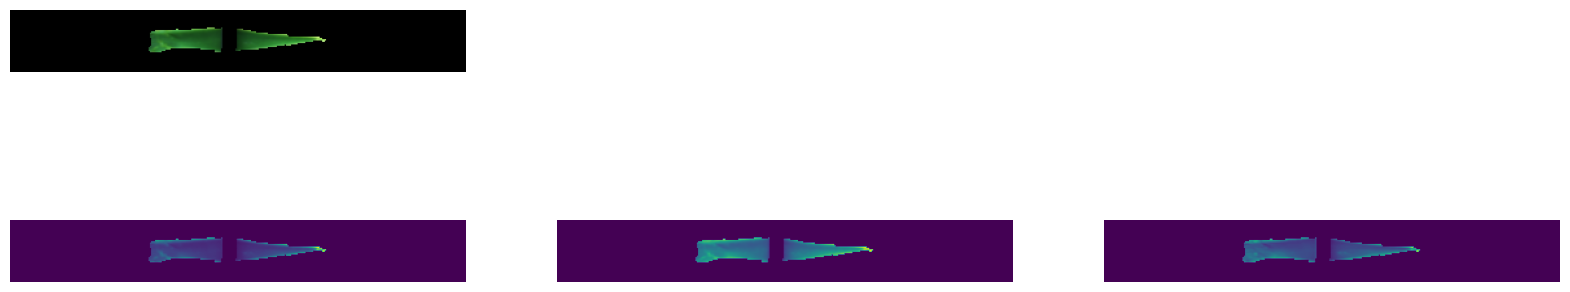

In [12]:
fig = plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.axis('off')
plt.imshow(rgb_preview/rgb_preview.max())
counter = 4
for i in rgb_indices:
    plt.subplot(2, 3, counter)
    plt.axis('off')
    plt.imshow(spectral_stack[:,:,i]/spectral_stack[:,:,i].max())

    counter += 1

# Сжатие и восстановление изображения

In [13]:
import teneva

In [14]:
hsi = spectral_stack

hsi_float_original = hsi.astype(np.float32)
#hsi_float_original /= hsi_float_original.max()

print("Shape оригинального HSI:", hsi_float_original.shape)

Shape оригинального HSI: (48, 352, 204)


In [15]:
# print(f"Максимальное значение цвета: {hsi_float_original.max()}")
# print(f"Минимальное значение цвета: {hsi_float_original.min()}")
# print(f"Среднее значение цвета: {round(hsi_float_original.mean(), 3)}")
# print(f"Тип данных: {np.dtype(hsi_float_original[0,0,0])}")
show_numpy_stats(hsi_float_original)

{'count': 3446784,
 'max': 64963.0,
 'min': 0.0,
 'mean': 2695.44921875,
 'median': 0.0,
 'std': 10542.7509765625,
 '25%': 0.0,
 '75%': 0.0,
 'dtype': 'float32'}


In [16]:
tt_decomp = teneva.svd(hsi_float_original, r=32)

In [17]:
print(f"Число ядер: {len(tt_decomp)}")
for i, core in enumerate(tt_decomp):
    print(f"Shape {i+1}-го ядра: {np.array(core).shape}")

Число ядер: 3
Shape 1-го ядра: (1, 48, 32)
Shape 2-го ядра: (32, 352, 32)
Shape 3-го ядра: (32, 204, 1)


In [18]:
hsi_reconstructed = teneva.full(tt_decomp)

In [19]:
# print(f"Максимальное значение цвета: {hsi_reconstructed.max()}")
# print(f"Минимальное значение цвета: {hsi_reconstructed.min()}")
# print(f"Среднее значение цвета: {round(hsi_reconstructed.mean(), 3)}")
# print(f"Тип данных: {np.dtype(hsi_reconstructed[0,0,0])}")
show_numpy_stats(hsi_reconstructed)

{'count': 3446784,
 'max': 65013.609375,
 'min': -0.008762728422880173,
 'mean': 2695.454345703125,
 'median': 0.0,
 'std': 10542.64453125,
 '25%': 0.0,
 '75%': 0.0,
 'dtype': 'float32'}


# Проверка метрик

In [20]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim


## Расчет PSNR для гиперспектральных изображений

**PSNR (Peak Signal-to-Noise Ratio)** — метрика для оценки качества восстановления изображений, измеряющая соотношение между максимальной возможной мощностью сигнала и мощностью искажающего шума. Для гиперспектральных изображений (HSI) расчет учитывает многомерные данные.

1. Среднеквадратичная ошибка (MSE)
Для гиперспектрального изображения размером \(W*H\) пикселей с \(C\) спектральными каналами MSE вычисляется как:

$$
\text{MSE} = \frac{1}{W \cdot H \cdot C} \sum_{c=1}^{C} \sum_{i=1}^{H} \sum_{j=1}^{W} \left[ X(i,j,c) - Y(i,j,c) \right]^2
$$

где:
- X — исходное изображение,
- Y — восстановленное/искаженное изображение,
- c — индекс спектрального канала.

2. PSNR
PSNR определяется через MSE и максимальное значение пикселя:

$$
\text{PSNR} = 10 \cdot \log_{10} \left( \frac{\text{MAX}_I^2}{\text{MSE}} \right)
$$
где $\text{MAX}_I$ — максимальное возможное значение пикселя.

In [21]:
psnr_value = psnr(hsi_float_original, hsi_reconstructed, data_range = hsi_float_original.max() - hsi_float_original.min())
print("PSNR:", psnr_value)

PSNR: 62.64459103119801


## Расчет SSIM для гиперспектральных изображений

**SSIM (Structural Similarity Index Measure)** — метрика для оценки качества восстановления изображений, измеряющая сходство структуры двух изображений на основе изменений яркости, контраста и корреляции. В отличие от PSNR, SSIM лучше согласуется с человеческим восприятием. Для гиперспектральных изображений (HSI) итоговый показатель обычно вычисляется как усреднение значений SSIM по всем спектральным каналам.

1. Индекс структурного сходства (SSIM)
Для каждого спектрального канала $c$ SSIM вычисляется на основе локальных статистик: среднего значения ($\mu$), дисперсии ($\sigma^2$) и ковариации ($\sigma_{xy}$):

$$
\text{SSIM}_c(X, Y) = \frac{(2\mu_X\mu_Y + C_1)(2\sigma_{XY} + C_2)}{(\mu_X^2 + \mu_Y^2 + C_1)(\sigma_X^2 + \sigma_Y^2 + C_2)}
$$

где:
- $X, Y$ — исходное и восстановленное изображения (или их локальные участки);
- $\mu_X, \mu_Y$ — средние значения яркости;
- $\sigma_X, \sigma_Y$ — стандартные отклонения (квадратный корень из дисперсии);
- $\sigma_{XY}$ — ковариация между $X$ и $Y$;
- $C_1, C_2$ — константы, stabilizing the division with weak denominators (зависят от динамического диапазона значений пикселей, например, $L=255$).

2. Средний SSIM (MSSIM)
Итоговая оценка качества для гиперспектрального куба данных получается путем усреднения показателей SSIM по всем $C$ каналам:

$$
\text{MSSIM} = \frac{1}{C} \sum_{c=1}^{C} \text{SSIM}_c(X_c, Y_c)
$$

где:
- $C$ — общее количество спектральных каналов в гиперспектральном изображении.

In [22]:
ssim_value = ssim(hsi_float_original, hsi_reconstructed, data_range = hsi_float_original.max() - hsi_float_original.min())
print("SSIM:", ssim_value)

SSIM: 0.9998858524022582


# Проверка степени сжатия

In [23]:
import pickle

In [24]:
with open('original.pkl', 'wb') as f:
    pickle.dump(hsi_float_original, f)
original_size = os.path.getsize('original.pkl')
print("Размер оригинального файла:", original_size, "bytes")

with open('tt_decomp.pkl', 'wb') as f:
    pickle.dump(tt_decomp, f)
tt_size = os.path.getsize('tt_decomp.pkl')
print("Размер TT-файла:", tt_size, "bytes")

compression_ratio = original_size / tt_size if tt_size > 0 else float('inf')
print("Compression ratio (original / TT):", compression_ratio)

Размер оригинального файла: 13787301 bytes
Размер TT-файла: 1474291 bytes
Compression ratio (original / TT): 9.351817924683797
